### Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic

### Data loading

In [5]:
functions = {}

for i in range(2, 9):
    X = np.load(f"function_{i}/initial_inputs.npy")
    y = np.load(f"function_{i}/initial_outputs.npy")

    functions[i] = {
        "X": X,
        "y": y
    }

### Reusable GP with kernel function

In [6]:
def run_gp_ucb(function_number, kernel, beta, n_candidates=10000):
    
    # Get data
    X = functions[function_number]["X"]
    y = functions[function_number]["y"]

    # Fit Gaussian Process using chosen kernel
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        optimizer=None
    )

    gp.fit(X, y)

    # Number of input dimensions
    n_dimensions = X.shape[1]

    # Generate candidate points
    candidates = np.random.RandomState(42).uniform(
        0, 1,
        size=(n_candidates, n_dimensions)
    )

    # GP predictions
    mean, std = gp.predict(candidates, return_std=True)

    # UCB
    ucb = mean + beta * std

    # Best candidate
    best_index = np.argmax(ucb)
    best_point = candidates[best_index]

    print(f"Function {function_number}")
    print(f"Kernel: {kernel}")
    print("Suggested point:", np.round(best_point, 6))
    print(f"Predicted mean: {mean[best_index]:.6f}")
    print(f"Uncertainty: {std[best_index]:.6f}")
    print(f"UCB: {ucb[best_index]:.6f}")

    return gp, best_point, mean[best_index], std[best_index]

### Reusable initial observations graph plot function

In [7]:
def plot_initial_observations(function_number):
    
    X = functions[function_number]["X"]
    y = functions[function_number]["y"]
    
    n_dimensions = X.shape[1]

    # 2D functions
    if n_dimensions == 2:
        
        plt.figure(figsize=(8, 6))
        
        scatter = plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            cmap="Blues",
            s=100,
            edgecolors="black"
        )
        
        for i in range(len(X)):
            plt.annotate(
                str(i),
                (X[i, 0], X[i, 1]),
                xytext=(5, 5),
                textcoords="offset points"
            )
        
        plt.colorbar(scatter, label="Observed y")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.title(f"Function {function_number}: Initial Observations")
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)
        plt.show()

    # 3D functions
    elif n_dimensions == 3:
        
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")
        
        scatter = ax.scatter(
            X[:, 0],
            X[:, 1],
            X[:, 2],
            c=y,
            cmap="Blues",
            s=80,
            edgecolors="black"
        )
        
        for i in range(len(X)):
            ax.text(
                X[i, 0],
                X[i, 1],
                X[i, 2],
                str(i)
            )
        
        fig.colorbar(scatter, ax=ax, label="Observed y")
        
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_zlabel("x3")
        ax.set_title(
            f"Function {function_number}: Initial Observations"
        )
        
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_zlim(0, 1)
        
        plt.show()

    else:
        print(
            f"Function {function_number} has {n_dimensions} dimensions. "
            "Direct spatial plotting is only used for 2D or 3D functions."
        )

### Reusable function which plots all 3 kernel results in one graph

In [38]:
def plot_kernel_comparison(
    function_number,
    rbf_point,
    matern_point,
    rq_point
):
    
    n_dimensions = len(rbf_point)

    # 2D
    if n_dimensions == 2:
        
        plt.figure(figsize=(8, 6))

        plt.scatter(
            rbf_point[0], rbf_point[1],
            marker="o", s=180,
            label="RBF"
        )

        plt.scatter(
            matern_point[0], matern_point[1],
            marker="s", s=180,
            label="Matérn"
        )

        plt.scatter(
            rq_point[0], rq_point[1],
            marker="^", s=180,
            label="Rational Quadratic"
        )

        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)

    # 3D
    elif n_dimensions == 3:
        
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            rbf_point[0], rbf_point[1], rbf_point[2],
            marker="o", s=180,
            label="RBF"
        )

        ax.scatter(
            matern_point[0], matern_point[1], matern_point[2],
            marker="s", s=180,
            label="Matérn"
        )

        ax.scatter(
            rq_point[0], rq_point[1], rq_point[2],
            marker="^", s=180,
            label="Rational Quadratic"
        )

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_zlabel("x3")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_zlim(0, 1)

    else:
        print(
            f"Function {function_number} has {n_dimensions} dimensions. "
            "Direct spatial plotting is only available for 2D or 3D."
        )
        return

    plt.title(
        f"Function {function_number}: Kernel GP-UCB Suggestions"
    )
    plt.legend()
    plt.show()

### Reusable input output comparison function

In [50]:
def plot_inputs_vs_output(function_number):
    
    X = functions[function_number]["X"]
    y = functions[function_number]["y"]
    
    n_dimensions = X.shape[1]
    
    fig, axes = plt.subplots(
        1, n_dimensions,
        figsize=(4 * n_dimensions, 4)
    )
    
    # Makes it work even if there is only one dimension
    axes = np.atleast_1d(axes)
    
    for i, ax in enumerate(axes):
        ax.scatter(X[:, i], y)
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("y")
        ax.set_title(f"x{i+1} vs y")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Function 2

In [9]:
X = functions[2]["X"]
y = functions[2]["y"]

df2 = pd.DataFrame(X, columns=["x1", "x2"])
df2["y"] = y

In [10]:
df2.shape

(10, 3)

In [11]:
display(df2)

,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


In [12]:
display(df2.sort_values("y", ascending=False))

,x1,x2,y
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993
6,0.438166,0.685018,0.244619
4,0.454647,0.290455,0.214965
7,0.341750,0.028698,0.038749
5,0.577713,0.771973,0.023106
8,0.338648,0.213867,-0.013858
2,0.142699,0.349005,-0.065624


#### graph plot of function 2 - coloured based on y value (higher means darker)

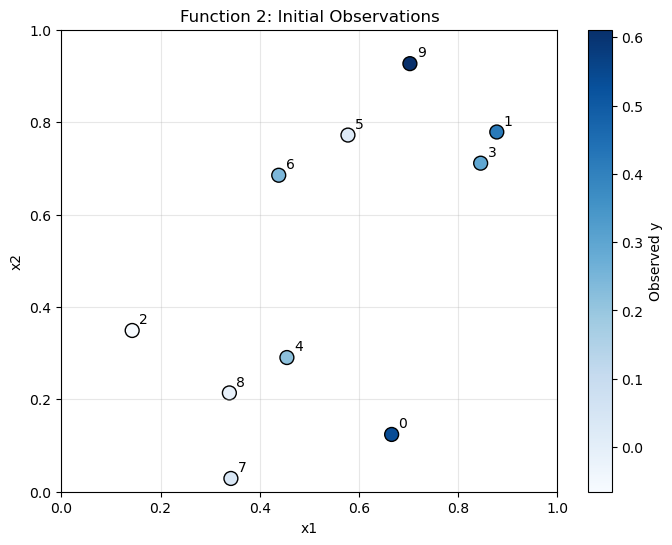

In [13]:
plot_initial_observations(2)

initial hypothesis (could be wrong) but from looking at the more promising data points they seem to be on very similar x1 region - it may be that x1: 0.65-0.75 is the optimal area

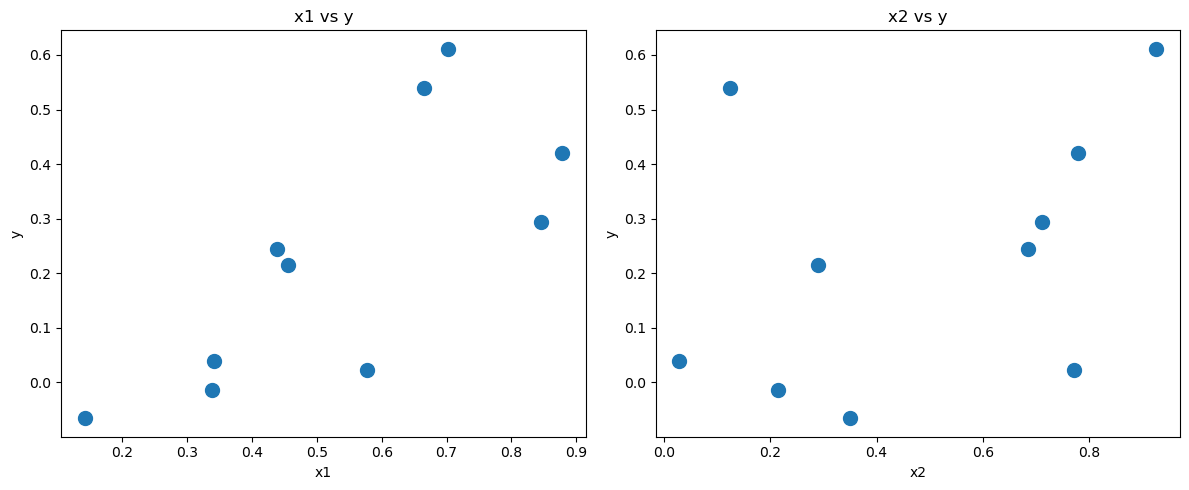

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df2["x1"], df2["y"], s=100)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("y")
axes[0].set_title("x1 vs y")

axes[1].scatter(df2["x2"], df2["y"], s=100)
axes[1].set_xlabel("x2")
axes[1].set_ylabel("y")
axes[1].set_title("x2 vs y")

plt.tight_layout()
plt.show()

There does seem to be a general positive trend in the `x1 vs y` graph, with the output increasing as `x1` increases before appearing to fall after approximately `x1 = 0.7`. However, the observation around `x1 = 0.58` does break this pattern slightly. My initial hypothesis that `x1` may be particularly influential therefore has some support, as the `x2 vs y` graph does not show an obvious trend. However, with only 10 observations, this is still preliminary and the interaction between `x1` and `x2` also needs to be considered.

#### trying GP with RBF 

In [15]:
kernel_rbf = RBF(length_scale=0.1)

gp2_rbf, point2_rbf, mean2_rbf, std2_rbf = run_gp_ucb(
    function_number=2,
    beta = 1.96,
    kernel=kernel_rbf
)

Function 2
Kernel: RBF(length_scale=0.1)
Suggested point: [0.799891 0.925328]
Predicted mean: 0.532661
Uncertainty: 0.166734
UCB: 0.859460


#### trying GP with Matern

In [16]:
kernel_matern = Matern(
    length_scale=0.1,
    nu=2.5
)

In [17]:
gp2_matern, point2_matern, mean2_matern, std2_matern = run_gp_ucb(
    function_number=2,
    kernel=kernel_matern,
    beta=1.96
)

Function 2
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.790415 0.916271]
Predicted mean: 0.498113
Uncertainty: 0.176011
UCB: 0.843094


#### trying GP with RQ

In [18]:
kernel_rq = RationalQuadratic(
    length_scale=0.1,
    alpha=1.0
)

In [19]:
gp2_rq, point2_rq, mean2_rq, std2_rq = run_gp_ucb(
    function_number=2,
    kernel=kernel_rq,
    beta=1.96
)

Function 2
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.794951 0.966673]
Predicted mean: 0.520404
Uncertainty: 0.164651
UCB: 0.843121


#### plotting all 3 suggestions on one graph

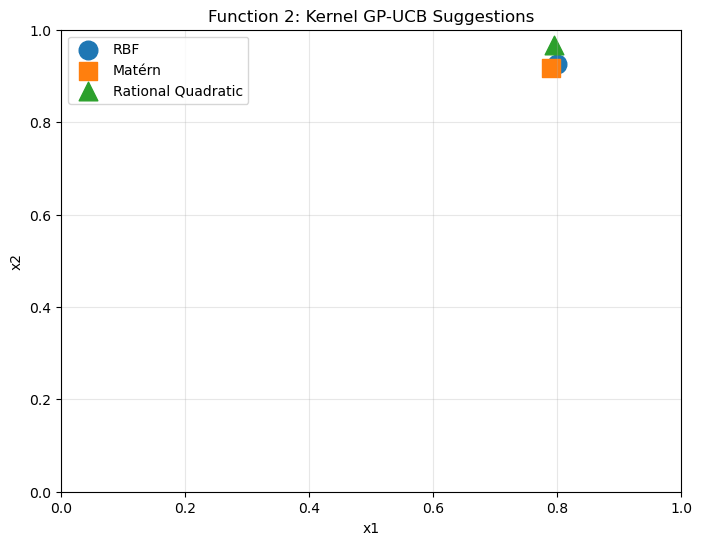

In [20]:
plot_kernel_comparison(
    2,
    point2_rbf,
    point2_matern,
    point2_rq
)

### final query choice

`(0.799891, 0.925328)` - RBF suggestion chosen as it sits nicely in the middle of the 3 kernel suggestions

### Function 3

In [21]:
X3 = functions[3]["X"]
y3 = functions[3]["y"]

df3 = pd.DataFrame(X3, columns=["x1", "x2", "x3"])
df3["y"] = y3

In [22]:
df3

,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


In [23]:
df3.sort_values("y", ascending=False)

,x1,x2,x3,y
3,0.492581,0.611593,0.340176,-0.034835
13,0.600097,0.725136,0.066089,-0.036378
10,0.220549,0.297825,0.343555,-0.046947
4,0.134622,0.219917,0.458206,-0.048008
14,0.965995,0.861120,0.566829,-0.056758
1,0.242114,0.644074,0.272433,-0.087963
9,0.170477,0.697032,0.149169,-0.094190
11,0.666014,0.671985,0.246295,-0.105965
5,0.345523,0.941360,0.269363,-0.110621
2,0.534906,0.398501,0.173389,-0.111415


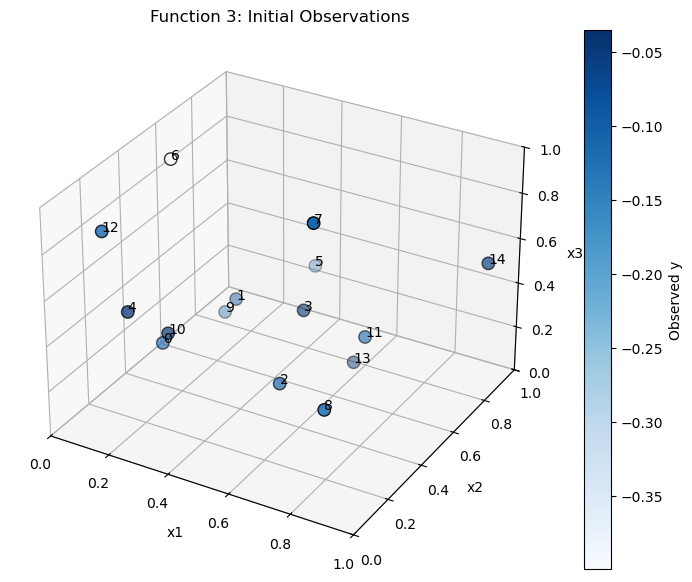

In [24]:
plot_initial_observations(3)

#### running GP with all kernels

In [52]:
gp3_rbf, point3_rbf, mean3_rbf, std3_rbf = run_gp_ucb(
    function_number=3,
    beta = 1.96,
    kernel=kernel_rbf
)

Function 3
Kernel: RBF(length_scale=0.1)
Suggested point: [0.491183 0.678883 0.145856]
Predicted mean: -0.074097
Uncertainty: 0.077663
UCB: 0.078121


In [53]:
gp3_rq, point3_rq, mean3_rq, std3_rq = run_gp_ucb(
    function_number=3,
    kernel=kernel_rq,
    beta=1.96
)

Function 3
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.454002 0.688274 0.140553]
Predicted mean: -0.069496
Uncertainty: 0.072039
UCB: 0.071702


In [54]:
gp3_matern, point3_matern, mean3_matern, std3_matern = run_gp_ucb(
    function_number=3,
    kernel=kernel_matern,
    beta=1.96
)

Function 3
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.491183 0.678883 0.145856]
Predicted mean: -0.077619
Uncertainty: 0.079006
UCB: 0.077233


### plotting all 3 kernels

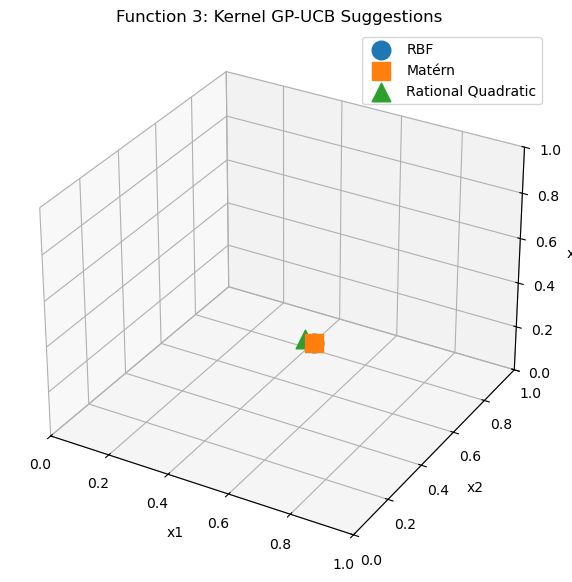

In [39]:
plot_kernel_comparison(
    3,
    point3_rbf,
    point3_matern,
    point3_rq
)

#### final query choice for function 3

The initial data showed no clear relationship between the individual inputs and the output, with the best observations spread across different areas. This suggests that interactions between the three variables may be important. All three GP kernels suggested a very similar region, with RBF and Matérn selecting the exact same point and RQ selecting a nearby point. I therefore selected `0.491183-0.678883-0.145856`, as the agreement between the models provides reasonable evidence for exploring this region while still balancing exploitation and uncertainty.

### Function 4

In [45]:
X4 = functions[4]["X"]
y4 = functions[4]["y"]

df4 = pd.DataFrame(X4, columns=["x1", "x2", "x3", "x4"])
df4["y"] = y4

In [46]:
df4.shape

(30, 5)

In [49]:
df4.sort_values("y", ascending=False)

,x1,x2,x3,x4,y
27,0.577766,0.428772,0.425826,0.249007,-4.025542
24,0.326076,0.472367,0.453192,0.105887,-6.702089
23,0.282138,0.505987,0.530531,0.096302,-7.966775
4,0.124871,0.129770,0.384400,0.287076,-10.069633
21,0.170347,0.756959,0.276520,0.531231,-11.565742
2,0.250946,0.033693,0.145380,0.494932,-11.699932
6,0.247708,0.060445,0.042186,0.441324,-12.681685
9,0.626071,0.586751,0.438806,0.778858,-12.741766
16,0.216911,0.166086,0.241372,0.770062,-12.758324
28,0.738613,0.482103,0.709366,0.503970,-13.122782


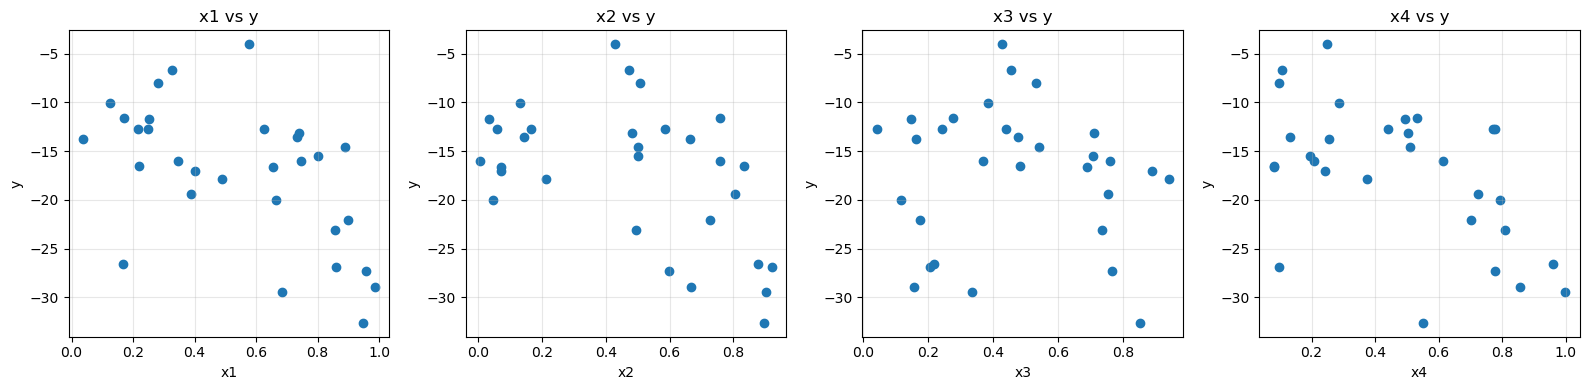

In [58]:
plot_inputs_vs_output(4)

# no obvious pattern shown 

In [56]:
gp_rbf_4, point_rbf_4, mean_rbf_4, std_rbf_4 = run_gp_ucb(
    4, kernel_rbf, beta=1.96
)

gp_matern_4, point_matern_4, mean_matern_4, std_matern_4 = run_gp_ucb(
    4, kernel_matern, beta=1.96
)

gp_rq_4, point_rq_4, mean_rq_4, std_rq_4 = run_gp_ucb(
    4, kernel_rq, beta=1.96
)

Function 4
Kernel: RBF(length_scale=0.1)
Suggested point: [0.517542 0.395784 0.479356 0.197097]
Predicted mean: -8.738569
Uncertainty: 5.598218
UCB: 2.233938
Function 4
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.517542 0.395784 0.479356 0.197097]
Predicted mean: -9.668631
Uncertainty: 5.986338
UCB: 2.064592
Function 4
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.45545  0.4683   0.410744 0.232992]
Predicted mean: -7.853043
Uncertainty: 5.577280
UCB: 3.078426


#### final query for 4

`0.517542-0.395784-0.479356-0.197097` due to RBF and Matern agreeing, RQ is also in a similar general area

### Function 5

In [59]:
X5 = functions[5]["X"]
y5 = functions[5]["y"]

df5 = pd.DataFrame(X5, columns=["x1", "x2", "x3", "x4"])
df5["y"] = y5

In [74]:
df5.shape

(20, 5)

In [60]:
df5.sort_values("y",ascending=False)

,x1,x2,x3,x4,y
15,0.224189,0.846480,0.879484,0.878516,1088.859618
18,0.119879,0.862540,0.643331,0.849804,431.612757
14,0.438933,0.774092,0.378167,0.933696,355.806818
4,0.836478,0.193610,0.663893,0.785649,258.370525
9,0.463442,0.630025,0.107906,0.957644,233.223610
7,0.352356,0.322242,0.116979,0.473113,109.571876
13,0.511142,0.817957,0.728710,0.112354,79.729130
5,0.683432,0.118663,0.829046,0.567577,78.434389
0,0.191447,0.038193,0.607418,0.414584,64.443440
11,0.583973,0.147243,0.348097,0.428615,64.420147


In [61]:
gp_rbf_5, point_rbf_5, mean_rbf_5, std_rbf_5 = run_gp_ucb(
    5, kernel_rbf, beta=1.96
)

gp_matern_5, point_matern_5, mean_matern_5, std_matern_5 = run_gp_ucb(
    5, kernel_matern, beta=1.96
)

gp_rq_5, point_rq_5, mean_rq_5, std_rq_5 = run_gp_ucb(
    5, kernel_rq, beta=1.96
)

Function 5
Kernel: RBF(length_scale=0.1)
Suggested point: [0.204881 0.87783  0.879582 0.870578]
Predicted mean: 1027.114226
Uncertainty: 89.276096
UCB: 1202.095374
Function 5
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.204881 0.87783  0.879582 0.870578]
Predicted mean: 993.757854
Uncertainty: 109.301215
UCB: 1207.988234
Function 5
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.204881 0.87783  0.879582 0.870578]
Predicted mean: 1028.004585
Uncertainty: 87.638553
UCB: 1199.776149


#### final query choice for f5

All three GP kernels then selected exactly the same new point, very close to the current best observation. This suggests a strong promising region, so I selected `0.204881-0.877830-0.879582-0.870578` to exploit around the apparent peak.

In [62]:
for beta in [0.5, 1, 1.96, 3, 5]:
    run_gp_ucb(5, kernel_rbf, beta=beta)
    print()

Function 5
Kernel: RBF(length_scale=0.1)
Suggested point: [0.204881 0.87783  0.879582 0.870578]
Predicted mean: 1027.114226
Uncertainty: 89.276096
UCB: 1071.752274

Function 5
Kernel: RBF(length_scale=0.1)
Suggested point: [0.204881 0.87783  0.879582 0.870578]
Predicted mean: 1027.114226
Uncertainty: 89.276096
UCB: 1116.390322

Function 5
Kernel: RBF(length_scale=0.1)
Suggested point: [0.204881 0.87783  0.879582 0.870578]
Predicted mean: 1027.114226
Uncertainty: 89.276096
UCB: 1202.095374

Function 5
Kernel: RBF(length_scale=0.1)
Suggested point: [0.162903 0.812414 0.853396 0.91434 ]
Predicted mean: 827.857164
Uncertainty: 172.804615
UCB: 1346.271007

Function 5
Kernel: RBF(length_scale=0.1)
Suggested point: [0.206796 0.779488 0.804547 0.822145]
Predicted mean: 654.098528
Uncertainty: 209.928200
UCB: 1703.739530



Completed a quick sanity check with the rbf kernel with different beta values - still shows the exact same point for 3 values of beta so my query decision remains.

### Function 6

In [78]:
X6 = functions[6]["X"]
y6 = functions[6]["y"]

df6 = pd.DataFrame(X6, columns=["x1", "x2", "x3", "x4", "x5"])
df6["y"] = y6

In [80]:
df6.sort_values("y", ascending=False)

,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
17,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757
10,0.536797,0.308781,0.411879,0.388225,0.522528,-1.144785
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
16,0.432166,0.715618,0.341819,0.705000,0.614962,-1.294247
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116
13,0.021735,0.428084,0.835939,0.489489,0.511082,-1.356682


In [81]:
gp_rbf_6, point_rbf_6, mean_rbf_6, std_rbf_6 = run_gp_ucb(
    6, kernel_rbf, beta=1.96
)

gp_matern_6, point_matern_6, mean_matern_6, std_matern_6 = run_gp_ucb(
    6, kernel_matern, beta=1.96
)

gp_rq_6, point_rq_6, mean_rq_6, std_rq_6 = run_gp_ucb(
    6, kernel_rq, beta=1.96
)

Function 6
Kernel: RBF(length_scale=0.1)
Suggested point: [0.700969 0.072763 0.82186  0.706242 0.081349]
Predicted mean: -1.147927
Uncertainty: 0.402132
UCB: -0.359748
Function 6
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.700969 0.072763 0.82186  0.706242 0.081349]
Predicted mean: -1.198568
Uncertainty: 0.415296
UCB: -0.384588
Function 6
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.65146  0.195108 0.704141 0.773151 0.124319]
Predicted mean: -1.062415
Uncertainty: 0.384850
UCB: -0.308110


In [82]:
for beta in [0.5, 1, 1.96, 3, 5]:
    run_gp_ucb(6, kernel_rbf, beta=beta)
    print()

Function 6
Kernel: RBF(length_scale=0.1)
Suggested point: [0.544776 0.331528 0.175228 0.768481 0.399976]
Predicted mean: -1.107820
Uncertainty: 0.365234
UCB: -0.925203

Function 6
Kernel: RBF(length_scale=0.1)
Suggested point: [0.544776 0.331528 0.175228 0.768481 0.399976]
Predicted mean: -1.107820
Uncertainty: 0.365234
UCB: -0.742585

Function 6
Kernel: RBF(length_scale=0.1)
Suggested point: [0.700969 0.072763 0.82186  0.706242 0.081349]
Predicted mean: -1.147927
Uncertainty: 0.402132
UCB: -0.359748

Function 6
Kernel: RBF(length_scale=0.1)
Suggested point: [0.700969 0.072763 0.82186  0.706242 0.081349]
Predicted mean: -1.147927
Uncertainty: 0.402132
UCB: 0.058469

Function 6
Kernel: RBF(length_scale=0.1)
Suggested point: [0.645068 0.230772 0.755817 0.727916 0.14203 ]
Predicted mean: -1.231716
Uncertainty: 0.422646
UCB: 0.881515



RBF and Matérn selected the same point near the current best observation. Although its predicted mean (`-1.148`) was lower than the current best output (`-0.714`), its relatively high uncertainty made it attractive under UCB. A beta sweep also showed that the point remained stable between `β=1.96` and `β=3`. I therefore selected `0.700969-0.072763-0.821860-0.706242-0.081349`, balancing exploitation of the promising region with exploration of uncertainty.

### Function 7

In [83]:
X7 = functions[7]["X"]
y7 = functions[7]["y"]

df7 = pd.DataFrame(X7, columns=["x1", "x2", "x3", "x4", "x5", "x6"])
df7["y"] = y7

In [84]:
df7.sort_values("y", ascending=False)

,x1,x2,x3,x4,x5,x6,y
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
24,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142
14,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
25,0.066611,0.528045,0.816095,0.961017,0.086509,0.777788,0.516457
23,0.175978,0.624416,0.295542,0.469553,0.097770,0.728141,0.475396
16,0.417626,0.064100,0.245669,0.559041,0.191531,0.254641,0.274893
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
13,0.942451,0.377440,0.486122,0.228791,0.082632,0.711958,0.268400


In [85]:
gp_rbf_7, point_rbf_7, mean_rbf_7, std_rbf_7 = run_gp_ucb(
    7, kernel_rbf, beta=1.96
)

gp_matern_7, point_matern_7, mean_matern_7, std_matern_7 = run_gp_ucb(
    7, kernel_matern, beta=1.96
)

gp_rq_7, point_rq_7, mean_rq_7, std_rq_7 = run_gp_ucb(
    7, kernel_rq, beta=1.96
)

Function 7
Kernel: RBF(length_scale=0.1)
Suggested point: [0.100466 0.554392 0.327801 0.220568 0.466257 0.666497]
Predicted mean: 0.674466
Uncertainty: 0.277283
UCB: 1.217941
Function 7
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.100466 0.554392 0.327801 0.220568 0.466257 0.666497]
Predicted mean: 0.610132
Uncertainty: 0.284040
UCB: 1.166850
Function 7
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.100466 0.554392 0.327801 0.220568 0.466257 0.666497]
Predicted mean: 0.797571
Uncertainty: 0.257159
UCB: 1.301603


#### testing local gb ucb 

since there is point 6 (`y = 1.365`), which is dramatically better than everything else, i will test a local search around that point

In [86]:
def run_local_gp_ucb(function_number, kernel, beta=1.96,
                     radius=0.15, n_candidates=10000):

    X = functions[function_number]["X"]
    y = functions[function_number]["y"]

    # Current best observed point
    best_observed = X[np.argmax(y)]

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        optimizer=None
    )
    gp.fit(X, y)

    # Define local region around current best
    lower = np.maximum(0, best_observed - radius)
    upper = np.minimum(1, best_observed + radius)

    rng = np.random.RandomState(42)
    candidates = rng.uniform(
        lower, upper,
        size=(n_candidates, X.shape[1])
    )

    mean, std = gp.predict(candidates, return_std=True)
    ucb = mean + beta * std

    best_index = np.argmax(ucb)
    point = candidates[best_index]

    print("Current best:", np.round(best_observed, 6))
    print("Local suggestion:", np.round(point, 6))
    print(f"Predicted mean: {mean[best_index]:.6f}")
    print(f"Uncertainty: {std[best_index]:.6f}")
    print(f"UCB: {ucb[best_index]:.6f}")

    return point

In [87]:
local_point_7 = run_local_gp_ucb(
    7,
    kernel_rbf,
    beta=1.96,
    radius=0.15
)

Current best: [0.057896 0.491672 0.247422 0.218118 0.420428 0.73097 ]
Local suggestion: [0.034286 0.50508  0.244574 0.201216 0.411612 0.773836]
Predicted mean: 1.208081
Uncertainty: 0.152624
UCB: 1.507223


#### now comparing the two...

Function 7 contained one particularly strong observation (`y = 1.365`), substantially higher than the next-best result. I therefore compared the global GP-UCB search with a local search around this point. While all three global kernels agreed on the same candidate, the local search produced a point with a substantially higher predicted mean (`1.208`) and UCB (`1.507`). I selected `0.034286-0.505080-0.244574-0.201216-0.411612-0.773836` to investigate whether the strong performance around the current best point can be improved further.

### Function 8

In [88]:
X8 = functions[8]["X"]
y8 = functions[8]["y"]

df8 = pd.DataFrame(X8, columns=["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"])
df8["y"] = y8

In [96]:
df8.sort_values("y", ascending = False).head()

,x1,x2,x3,x4,x5,x6,x7,x8,y
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
26,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274
39,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005
22,0.145120,0.119328,0.420888,0.387609,0.155423,0.875172,0.510560,0.728611,9.141639
19,0.044329,0.013581,0.258198,0.577644,0.051280,0.158563,0.591030,0.077953,9.013075


In [97]:
df8.sort_values("y", ascending = False).tail()

,x1,x2,x3,x4,x5,x6,x7,x8,y
17,0.735904,0.034612,0.728030,0.147427,0.295743,0.445117,0.975180,0.374340,6.767963
24,0.176150,0.293961,0.975680,0.793936,0.923401,0.030842,0.803255,0.595898,6.451943
34,0.964573,0.973980,0.663753,0.662216,0.673122,0.905238,0.458875,0.560918,6.402588
21,0.898887,0.523642,0.876783,0.218696,0.900261,0.282766,0.911078,0.472398,5.841067
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [98]:
gp_rbf_8, point_rbf_8, mean_rbf_8, std_rbf_8 = run_gp_ucb(
    8, kernel_rbf, beta=1.96
)

gp_matern_8, point_matern_8, mean_matern_8, std_matern_8 = run_gp_ucb(
    8, kernel_matern, beta=1.96
)

gp_rq_8, point_rq_8, mean_rq_8, std_rq_8 = run_gp_ucb(
    8, kernel_rq, beta=1.96
)

Function 8
Kernel: RBF(length_scale=0.1)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.171257
Uncertainty: 0.912162
UCB: 9.959095
Function 8
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.133490
Uncertainty: 0.919293
UCB: 9.935304
Function 8
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.457315
Uncertainty: 0.852590
UCB: 10.128391


In [99]:
for beta in [0.5, 1, 1.96, 3, 5]:
    run_gp_ucb(8, kernel_rbf, beta=beta)
    print()

Function 8
Kernel: RBF(length_scale=0.1)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.171257
Uncertainty: 0.912162
UCB: 8.627338

Function 8
Kernel: RBF(length_scale=0.1)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.171257
Uncertainty: 0.912162
UCB: 9.083419

Function 8
Kernel: RBF(length_scale=0.1)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.171257
Uncertainty: 0.912162
UCB: 9.959095

Function 8
Kernel: RBF(length_scale=0.1)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.171257
Uncertainty: 0.912162
UCB: 10.907743

Function 8
Kernel: RBF(length_scale=0.1)
Suggested point: [0.076274 0.101214 0.383035 0.338493 0.113685 0.882235 0.615428 0.796463]
Predicted mean: 8.171257
Uncertainty: 0.912162
UCB: 12.732067



#### final query choice for function 8

Function 8 is particularly challenging because only 40 observations are available across eight dimensions. All three GP kernels selected exactly the same candidate point. A beta sweep from 0.5 to 5 also produced the same suggestion throughout, showing that the selected location was stable despite changing the exploration weight. Although its predicted mean was below the current best observation, its high uncertainty made the region valuable to investigate - exploration. I therefore selected `0.076274-0.101214-0.383035-0.338493-0.113685-0.882235-0.615428-0.796463` for my first query.